In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
import os
import sys

In [23]:
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 80)
pd.set_option('display.float_format', '{:,.2f}'.format)

In [5]:
for pkg in ['pandas', 'numpy', 'matplotlib']:
    mod = __import__(pkg)
    print(f"{pkg}: {mod.__version__}")
print(f"Python: {sys.version.split()[0]}")

pandas: 2.2.3
numpy: 2.1.3
matplotlib: 3.10.0
Python: 3.13.9


In [34]:
RAW_PATH = '../data/raw/L4_Tidy_2024_ALL_LA.csv'
OUTPUT_DIR = '../outputs/phase1'

In [7]:
#Sentinel strings that are used in the dataset
SENTINELS = {
    'c': 'suppressed - small number, confidentiality',
    'z': 'not applicable',
    'x': 'not available',
    'low': 'positive value, less than 0.5%',
    '0': 'true zero'
}

In [8]:
#Feature columns that are numeric
NUM_COLS = [
    'all_cohort', 'all_progressed', 'all_degree', 'all_top3rd', 'all_appren', 'all_htech', 'acag_cohort', 'acag_progressed',
    'tlev_cohort', 'tlev_progressed', 'otl3_cohort', 'otl3_progressed'
]

In [9]:
#There were cohort break years according to documentation the composition criteria changed for these years
COHORT_BREAK_YEARS = [202021, 202122]

In [18]:
df = pd.read_csv(RAW_PATH, low_memory=False)

print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")

Shape: 44,342 rows x 30 columns


In [19]:
#Column Names
print("Column Names:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:2d}. {col}")

Column Names:
   1. time_period
   2. time_identifier
   3. geographic_level
   4. country_code
   5. country_name
   6. region_code
   7. region_name
   8. old_la_code
   9. new_la_code
  10. la_name
  11. pcon_code
  12. pcon_name
  13. level_methodology
  14. institution_group
  15. institution_type
  16. breakdown_topic
  17. breakdown
  18. data_type
  19. all_cohort
  20. all_progressed
  21. all_degree
  22. all_top3rd
  23. all_appren
  24. all_htech
  25. acag_cohort
  26. acag_progressed
  27. tlev_cohort
  28. tlev_progressed
  29. otl3_cohort
  30. otl3_progressed


In [24]:
df.head(3).T

,0,1,2
time_period,202122,202122,202122
time_identifier,Academic year,Academic year,Academic year
geographic_level,Local authority,Local authority,Local authority
country_code,E92000001,E92000001,E92000001
country_name,England,England,England
region_code,E12000001,E12000001,E12000001
region_name,North East,North East,North East
old_la_code,390.00,390.00,390.00
new_la_code,E08000037,E08000037,E08000037
la_name,Gateshead,Gateshead,Gateshead


In [25]:
#Determining the types of columns

print(df.dtypes)

time_period            int64
time_identifier       object
geographic_level      object
country_code          object
country_name          object
region_code           object
region_name           object
old_la_code          float64
new_la_code           object
la_name               object
pcon_code             object
pcon_name             object
level_methodology     object
institution_group     object
institution_type      object
breakdown_topic       object
breakdown             object
data_type             object
all_cohort            object
all_progressed        object
all_degree            object
all_top3rd            object
all_appren            object
all_htech             object
acag_cohort           object
acag_progressed       object
tlev_cohort           object
tlev_progressed       object
otl3_cohort           object
otl3_progressed       object
dtype: object


In [28]:
'''Before we do any transformation it is important that we know exactly how many sentinel strings exist in each numeric column.
This will drive our imputation strategy later on '''

sentinel_keys = list(SENTINELS.keys())
sentinel_keys

['c', 'z', 'x', 'low', '0']

In [33]:
rows = []
for col in NUM_COLS:
    col_str = df[col].astype(str).str.strip()
    total = len(col_str)
    row = {'column': col}
    for s in sentinel_keys:
        count = (col_str == s).sum()
        row[s] = count
    #Anything that is not a digit, sentinel or decimal point
    is_numeric = pd.to_numeric(df[col], errors='coerce').notna()
    row['numeric'] = is_numeric.sum()
    row['total'] = total
    row['pct_clean'] = f"{is_numeric.mean()*100:.1f}%"
    rows.append(row)

audit = pd.DataFrame(rows).set_index('column')
print("Sentinel counts per numeric column:")
print()
print(audit.to_string())

Sentinel counts per numeric column:

                   c    z  x  low      0  numeric  total pct_clean
column                                                            
all_cohort         0    0  0    2    510    44340  44342    100.0%
all_progressed    24  255  0    1    313    44062  44342     99.4%
all_degree        16  255  0    1    343    44070  44342     99.4%
all_top3rd        24  255  0   10   1242    44053  44342     99.3%
all_appren        84  255  0  362   4289    43641  44342     98.4%
all_htech        100  255  0   94   3457    43893  44342     99.0%
acag_cohort       24    0  0    8    914    44310  44342     99.9%
acag_progressed   48  255  0    2    760    44037  44342     99.3%
tlev_cohort      152    0  0   66   8318    44124  44342     99.5%
tlev_progressed  304  255  0   92   9136    43691  44342     98.5%
otl3_cohort      156    0  0   66   8904    44120  44342     99.5%
otl3_progressed  316  255  0  104  10389    43667  44342     98.5%


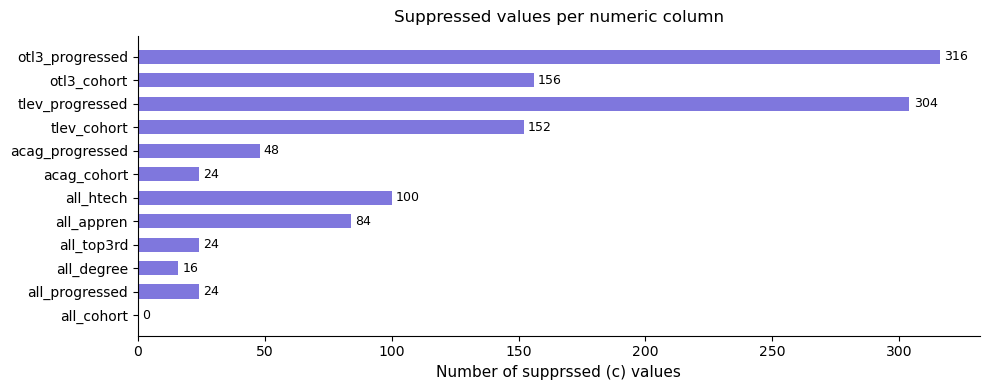

In [39]:
#Lets visualise suppression ('c') by column
fig, ax = plt.subplots(figsize=(10,4))
colors = ['#7F77DD' if v > 0 else '#D3D1C7' for v in audit['c']]
bars = ax.barh(audit.index, audit['c'], color=colors, height=0.6)
ax.set_xlabel('Number of supprssed (c) values', fontsize=11)
ax.set_title('Suppressed values per numeric column', fontsize=12, pad=10)
ax.bar_label(bars, padding=3, fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/sentinel_suppressed_counts.png', dpi=150, bbox_inches='tight')
plt.show()

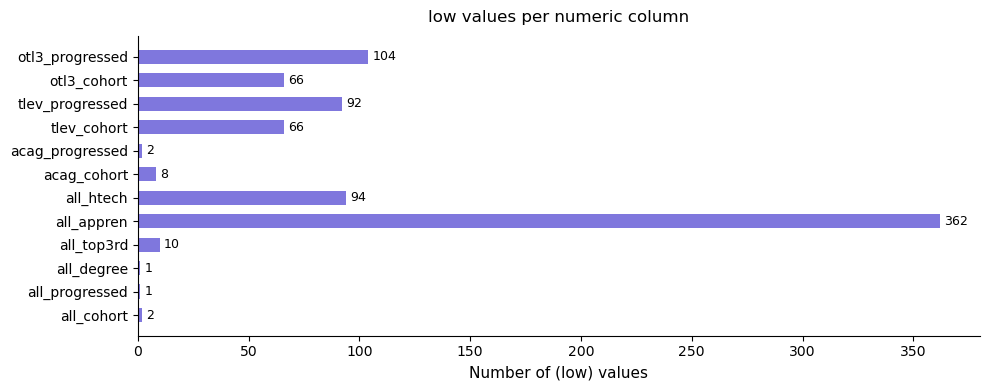

In [40]:
#Lets visualise ('low') by column
fig, ax = plt.subplots(figsize=(10,4))
colors = ['#7F77DD' if v > 0 else '#D3D1C7' for v in audit['low']]
bars = ax.barh(audit.index, audit['low'], color=colors, height=0.6)
ax.set_xlabel('Number of (low) values', fontsize=11)
ax.set_title('low values per numeric column', fontsize=12, pad=10)
ax.bar_label(bars, padding=3, fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/sentinel_low_counts.png', dpi=150, bbox_inches='tight')
plt.show()

In [46]:
print("KEY FINDINGS: ")
print(f"'z'(not applicable) dominates progression columns - these rows have qualification types with no applicable students.")
print(f"'c' suppression is heaviest in tlev/otl3 columns which is basically tech level and other L3. These are the smallest qualification cohorts.")
print(f"'low' appears in all_appren (362 times) which means a significant share of apprenticeship rates will be coerced to a mid-point value in further analysis")

KEY FINDINGS: 
'z'(not applicable) dominates progression columns - these rows have qualification types with no applicable students.
'c' suppression is heaviest in tlev/otl3 columns which is basically tech level and other L3. These are the smallest qualification cohorts.
'low' appears in all_appren (362 times) which means a significant share of apprenticeship rates will be coerced to a mid-point value in further analysis


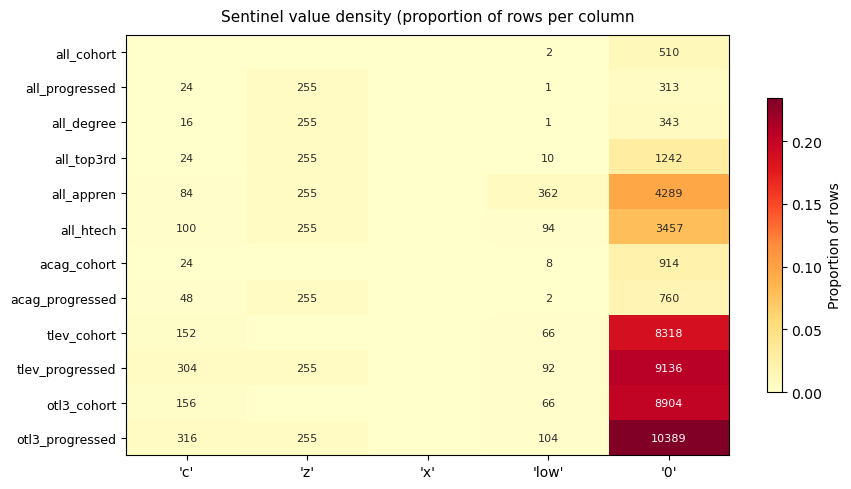

In [49]:
fig, ax = plt.subplots(figsize=(9,5))

heat_data = audit[sentinel_keys].values

heat_norm = heat_data / audit['total'].values.reshape(-1,1)

im = ax.imshow(heat_norm, aspect='auto', cmap='YlOrRd', vmin=0)
ax.set_xticks(range(len(sentinel_keys)))
ax.set_xticklabels([f"'{s}'" for s in sentinel_keys], fontsize=10)
ax.set_yticks(range(len(NUM_COLS)))
ax.set_yticklabels(NUM_COLS, fontsize=9)
ax.set_title('Sentinel value density (proportion of rows per column', fontsize=11, pad=10)

for i in range(len(NUM_COLS)):
    for j in range(len(sentinel_keys)):
        val = heat_data[i, j]
        if val > 0:
            ax.text(j, i, str(val), ha='center', va='center', fontsize=8,
                   color = 'white' if heat_norm[i,j] > 0.15 else '#2C2C2A')


plt.colorbar(im, ax=ax, label='Proportion of rows', shrink=0.7)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/sentinel_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()